# Python Programming

Building on Python basics, this session focuses on writing **structured, reusable, and maintainable** Python programs.

## Learning Objectives

By the end of this session, you will be able to:
- Define Python **functions** with docstrings, multiple return values, and flexible arguments
- Explain **variable scope** (local vs. global, the LEGB rule)
- Read and write data files with NumPy (`loadtxt`, `save`, `load`, `savez`)
- Control program flow with `if / elif / else`, `for`, and `while`
- Use **higher-order functions** (`lambda`, `partial`, `filter`) and decorators

## Session Outline 

| # | Topic |  
|---|-------|
| 1 | Script Files & Functions | 
| 2 | Variable Scope | 
| 3 | Input / Output & File I/O | 
| 4 | Structured Programming | 
| 5 | Higher-Order Functions & Classes | 
| 6 | Wrap-up & Q&A | 

---
## 1. Script Files & Python Functions

A **Python script** is a `.py` file (or notebook cell) containing a sequence of statements executed top to bottom in a shared environment.

**Good script habits:**
- Use `#` comments to explain *why*, not *what*
- Use `"""docstrings"""` at the top of files and functions
- Group related logic into **functions** — avoids copy-pasting (DRY: Don't Repeat Yourself)

The following example computes the **bungee jumper velocity** first as a plain script, then refactors it into a reusable function.

### The Bungee Jumper Problem

We model the **free-falling bungee jumper** — a classic problem in numerical methods.

<img src="./figures/bungee.png" width="120" />

<sub><sub>(from Applied Numerical Methods with Python for Engineers and Scientists)</sub></sub>

The equation of motion (Newton's 2nd Law with quadratic air drag) is:

$$\frac{dv}{dt} = g - \frac{c_d}{m}v^2$$

where $v$ = downward velocity, $g$ = gravitational acceleration, $c_d$ = drag coefficient, $m$ = mass.

The **exact (analytical) solution** is:

$$v(t) = \sqrt{\frac{gm}{c_d}} \tanh\!\left(\sqrt{\frac{gm}{c_d}}\, t\right)$$

In [1]:
""" 
This is example 3.1. which computes the velocity of the free-falling bungee jumper.

"""

import math
g = 9.81 # [m/s] 
m = 68.1 # [kg] 
t = 12 # [sec]
cd = 0.25 # [kg/m]
v = math.sqrt(m*g/cd)*math.tanh(math.sqrt(m*g/cd)*t)
print('velocity =', v, 'm/s')

velocity = 51.69375204026111 m/s


> **Observation:** The script above works — but it is not reusable. If we want the velocity for a different mass or drag coefficient, we have to modify and re-run the entire cell. The solution: **wrap it in a function** so we can call it with any parameters.

### Defining Python Functions

A function encapsulates reusable logic under a name:

```python
def function_name(param1, param2):
    """Short description.

    Args:
        param1: description
        param2: description
    Returns:
        description of return value
    """
    result = ...
    return result
```

Key points:
- Defined with `def`, called by name: `result = function_name(arg1, arg2)`
- The **docstring** (first `"""..."""` inside) is stored in `func.__doc__`
- `return` exits the function and passes a value back (`None` if omitted)
- Functions can return **multiple values** as a **tuple**: `return a, b, c`

In [2]:
# example 3.2
import math
import scipy.constants as pc

def freefall(t,m,cd):
    """ 
    This function computes bungee jumper velocity with 2nd-order drag.
    input arguments: 
        t: time 
        m: mass
        cd: drag coeffcient
    output:
        v: velocity
    """ 
    g = pc.g 
    return math.sqrt(m*g/cd)*math.tanh(math.sqrt(m*g/cd)*t)

freefall(12,68.1,0.25)


51.684924881439066

In [3]:
# different arguments
v = freefall(8,100,0.25)
print('velocity={0:g} m/s'.format(v))

velocity=62.6311 m/s


In [4]:
# see the docstring
print(freefall.__doc__)

 
    This function computes bungee jumper velocity with 2nd-order drag.
    input arguments: 
        t: time 
        m: mass
        cd: drag coeffcient
    output:
        v: velocity
    


In [5]:
# Python function can return more than one result.
import numpy as np 
def stats(x):
    n = len(x)
    avg = np.average(x)
    s = np.std(x)
    return n, avg, s 

y = [8,5,10,12,6,7,5,4]
z = stats(y)
print(z)
print(type(z)) 

_n, _avg, _s = stats(y)
print('n = ',_n)
print('avg = ',_avg)
print('s = ',_s)


(8, np.float64(7.125), np.float64(2.5708704751503917))
<class 'tuple'>
n =  8
avg =  7.125
s =  2.5708704751503917


### Variable Scope — the LEGB Rule

Python resolves variable names by searching scopes in this order:

| Level | Where | Example |
|-------|-------|---------|
| **L**ocal | Inside the current function | `x` assigned with `=` inside `def` |
| **E**nclosing | Outer function(s) for nested functions | outer `def` scope |
| **G**lobal | Module-level (top of the script / notebook) | top-level `x = 88` |
| **B**uilt-in | Python's own names | `len`, `print`, `range` |

**A variable assigned inside a function is local by default — invisible outside.**

The next cell intentionally raises a `NameError` to demonstrate this — the error is the lesson!

**What happened?**
- `x = 88` is in the **global** scope → `adder()` can read it ✔
- `s = a + b` is created *inside* `adder()` → it is **local** to that function
- `print('s =', s)` in the global scope cannot see the local `s` → `NameError` ✔

This is the expected result and demonstrates scope isolation between function and global namespaces.

**What happened?**
- `x1` is **local** to `sgnsqr()` — it does not exist in `sgnsqrt()` or the global scope
- Functions have **isolated** local namespaces; one function cannot read another's local variables

The fixed version below removes the invalid cross-function reference:

In [6]:
# local variable s cannt be seen from the general script!
# global variable x can be seen within the function.
def adder(a,b):
    print('x=',x)
    s = a + b 
    return s 
x = 88
c = 1 
d = 5
print('sum = ', adder(c,d))
print('s =', s)

x= 88
sum =  6


NameError: name 's' is not defined

> **Warning — avoid `global`:** The `global` keyword lets a function write to a module-level variable. This works but creates **hidden side effects** that make code hard to understand and debug. The recommended practice is to **pass values as arguments** and **return results** instead of relying on global state.

In [7]:
import numpy as np 

def sgnsqr(x):
    x1 = x* abs(x)
    return x1 

def sgnsqrt(x):
    print('x1=',x1)
    x2 = np.sqrt(abs(x))* np.sign(x)
    return x2 

x = -2.0
print('x squared with sign = ', sgnsqr(x))
print('square root of x with sign = ', sgnsqrt(x))
print('x2=',x2)
    

x squared with sign =  -4.0


NameError: name 'x1' is not defined

In [8]:
import numpy as np 

def sgnsqr(x):
    x1 = x* abs(x)
    return x1 

def sgnsqrt(x):
    x2 = np.sqrt(abs(x))* np.sign(x)
    return x2 

x = -2.0
print('x squared with sign = ', sgnsqr(x))
print('square root of x with sign = ', sgnsqrt(x))
    

x squared with sign =  -4.0
square root of x with sign =  -1.4142135623730951


In [9]:
# we can change the scope of a variable in a function from local to global.

# local variable s cannt be seen from the general script!
# global variable x can be seen within the function.
def adder(a,b):
    global x 
    x = 88 
    s = a + b 
    return s 
c = 1 
d = 5
print('sum = ', adder(c,d))
print('x =', x)

sum =  6
x = 88


In [10]:
# We consider a function embedded within another function. 
# This is a nested function in Python.
# The inner function can access variables and parameters of the outer function,
# enhancing encapsulation and modularity in programming.

def fun1(x):
    b = -1
    d = 0.1
    def fun2(a,x):
        c = d*a*x**5
        return c 
    return fun2(b,x)

x = 2
print('fun1 result=', fun1(x))
 

fun1 result= -3.2


In [11]:
# fun2 cannot be invoked from outside the fun1 function.
print('fun2 result=', fun2(1,x))

NameError: name 'fun2' is not defined

#### Keyword vs. Positional Arguments

| Type | How it works | Example |
|------|-------------|---------|
| **Positional** | Matched by order; always required | `f(5, 2)` |
| **Keyword** | Matched by name; has a default value | `f(5, print_input=True)` |

Rules:
- Positional arguments **must come before** keyword arguments in the function call
- Keyword arguments with defaults are **optional** — the default is used when not passed
- You can call any argument by name to improve readability: `freefall(t=12, m=68.1, cd=0.25)`

In [13]:
def func_keyword_argument(a,print_input=False):
    if print_input==True:
        print(a)

func_keyword_argument(5)
func_keyword_argument(5,print_input=True)

5


In [14]:
def func_positional_argument(a,b):
    return a + b

func_positional_argument(5,2)

7

#### Variable-Length Arguments: `*args` and `**kwargs`

Use these when you don't know in advance how many arguments a function will receive.

| Syntax | Name | What it receives |
|--------|------|-----------------|
| `*args` | Variable positional args | A **tuple** of extra positional arguments |
| `**kwargs` | Variable keyword args | A **dict** of extra keyword `name=value` pairs |

```python
def f(*args, **kwargs):
    print(args)    # tuple: (1, 2, 3)
    print(kwargs)  # dict:  {'a': 10, 'b': 20}

f(1, 2, 3, a=10, b=20)
```

`*args` and `**kwargs` can be combined with regular parameters: `def f(x, *args, **kwargs)`

In [56]:
def func(*args):
    return sum(args)

print(func(1,2,3))
print(func(1,2,3,4))

6
10


In [15]:
def func(**kwargs): #key-value pairs
    print(kwargs.items())
    print(len(kwargs.items()))
    for k,v in kwargs.items():
        print(k,v)

func(a=1,b=2,c=3)
func(a=1,b=2,c=3,d=4)

dict_items([('a', 1), ('b', 2), ('c', 3)])
3
a 1
b 2
c 3
dict_items([('a', 1), ('b', 2), ('c', 3), ('d', 4)])
4
a 1
b 2
c 3
d 4


---
## 3. Input / Output

### Console I/O

```python
name = input("Enter your name: ")   # always returns a string — cast if needed
age  = int(input("Enter your age: "))
print(f"Hello, {name}! You are {age} years old.")
```

> In scientific computing, we rarely use `input()` interactively. Instead, we read data from **files**. NumPy provides efficient tools for this.

### NumPy File I/O

| Format | Save | Load | Notes |
|--------|------|------|-------|
| Text (`.txt`, `.csv`) | — | `np.loadtxt()` | Human-readable |
| Binary (`.npy`) | `np.save()` | `np.load()` | Fast, single array |
| Multi-array (`.npz`) | `np.savez()` | `np.load()` → dict-like | Fast, multiple arrays |

### Real Data: KMA Automatic Weather Station

We use hourly temperature data from the **Korea Meteorological Administration (KMA)** AWS at Goun-dong, Sejong-si.

<img src="./figures/aws.jpeg" width="300" />

- Source: https://data.kma.go.kr/resources/html/en/aowdp.html
- File format: 3 columns — station ID, hour (1–23), temperature (°C)

**Key `np.loadtxt` arguments:**

```python
np.loadtxt(fname, dtype=float, comments='#', delimiter=None,
           skiprows=0, usecols=None, unpack=False)
```

- `skiprows=2` — skip the two header lines
- `unpack=True` — transposes the result so each **column** is returned as a separate 1-D array

In [16]:
# read data file
# https://data.kma.go.kr/cmmn/static/staticPage.do?page=intro

import numpy as np 
_, t, temp = np.loadtxt('./data/awsdata.txt',skiprows=2,unpack=True)
print(t)
print(temp)


[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23.]
[2.1 1.8 1.3 0.9 0.7 0.3 0.2 0.8 1.8 4.8 6.4 7.8 8.7 9.3 9.3 9.7 9.  8.1
 7.1 6.1 5.3 5.2 4.3]


In [21]:
# for google colab
t = np.squeeze(np.array(np.matrix('1.  2.  3.  4.  5.  6.  7.  8.  9. 10. \
            11. 12. 13. 14. 15. 16. 17. 18. 19. 20. \
                21. 22. 23.')))
print(t)
temp = np.squeeze(np.array(np.matrix('2.1 1.8 1.3 0.9 0.7 0.3 0.2 0.8 1.8 4.8 6.4 7.8 \
                 8.7 9.3 9.3 9.7 9.  8.1 7.1 6.1 5.3 5.2 4.3')))
print(temp)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23.]
[2.1 1.8 1.3 0.9 0.7 0.3 0.2 0.8 1.8 4.8 6.4 7.8 8.7 9.3 9.3 9.7 9.  8.1
 7.1 6.1 5.3 5.2 4.3]


Text(0, 0.5, 'Temperature [degC]')

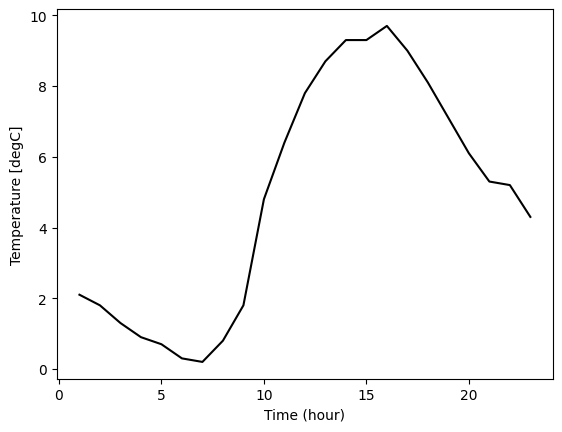

In [22]:
import matplotlib.pyplot as plt 

plt.plot(t,temp,'k')
plt.xlabel('Time (hour)')
plt.ylabel('Temperature [degC]')

In [23]:
# save data as numpy array 
print(type(t))
print(type(temp))

np.save('awsdata-t.npy',t)
np.save('awsdata-temp.npy',temp)


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [24]:
# delete t and temp
del(t,temp)
print(t)
print(temp)

NameError: name 't' is not defined

In [25]:
# load awsdata 
t = np.load('awsdata-t.npy')
print(t)
temp = np.load('awsdata-temp.npy')
print(temp)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23.]
[2.1 1.8 1.3 0.9 0.7 0.3 0.2 0.8 1.8 4.8 6.4 7.8 8.7 9.3 9.3 9.7 9.  8.1
 7.1 6.1 5.3 5.2 4.3]


In [26]:
# Save several arrays into a single file in uncompressed .npz format. 
np.savez('awsdata.npz',t=t, temp=temp)

In [27]:
# access the data with keyword names
data = np.load('awsdata.npz')
print(data)
print(data['t'])
print(data['temp'])

NpzFile 'awsdata.npz' with keys: t, temp
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23.]
[2.1 1.8 1.3 0.9 0.7 0.3 0.2 0.8 1.8 4.8 6.4 7.8 8.7 9.3 9.3 9.7 9.  8.1
 7.1 6.1 5.3 5.2 4.3]


---
## 4. Structured Programming

Control structures let your program **make decisions** and **repeat actions**.

| Structure | Keywords | Purpose |
|-----------|----------|---------|
| Conditional | `if`, `elif`, `else` | Execute a block only when a condition is `True` |
| Definite loop | `for` | Iterate over a sequence a known number of times |
| Indefinite loop | `while` | Repeat as long as a condition holds |
| Early exit | `break`, `continue` | Exit or skip iterations inside a loop |

**Comparison operators:** `==`, `!=`, `<`, `>`, `<=`, `>=`

**Logical operators:** `and`, `or`, `not`

#### `if` — Conditional Execution

```python
if condition:
    statements        # runs only when condition is True
```

The `condition` is any expression that evaluates to a boolean. Python treats `0`, `None`, empty strings/lists as `False`; everything else as `True`.

In [31]:
a = 5
b = 10
if a < b: 
    print('a is smaller than b')

a is smaller than b


#### `if / else` — Two-Way Branch

```python
if condition:
    statements    # runs when condition is True
else:
    statements    # runs when condition is False
```

In [28]:
a = 10
b = 5
if a <= b: 
    print('a is smaller than or equal to b')
else:
    print('a is larger than b')

a is larger than b


In [29]:
def tempconvert(t_in, units='degF'):
    if units == 'degF':
        return print('{0:5.2f} degC'.format((t_in-32)/1.8))
    else:
        return print('{0:5.2f} degF'.format(t_in*1.8+32))
    
tempconvert(98.6)
tempconvert(37,units='degC')

37.00 degC
98.60 degF


#### `if / elif / else` — Multi-Way Branch

```python
if condition1:
    statements
elif condition2:     # "else if" — checked only when condition1 is False
    statements
else:               # fallback — runs when no condition above is True
    statements
```

Conditions are tested **top to bottom**; only the first matching block executes.

In [30]:
def compare_a_and_b(a,b):
    if a < b: 
        print('a is smaller than b')
    elif a == b:
        print('a is equal to b')
    else:
        print('a is larger than b')

compare_a_and_b(5,10)
compare_a_and_b(5,5)
compare_a_and_b(5,1)

a is smaller than b
a is equal to b
a is larger than b


#### `for` Loop — Iterating Over Sequences

```python
for item in iterable:
    statements
```

Python's `for` loop iterates over **any iterable**: lists, strings, NumPy arrays, `range()`, etc.

`range(start, stop, step)` generates integers — `stop` is **not included** (same convention as NumPy slicing).

In [31]:
for icolor in ['red','blue','green','black']:
    print(icolor)

red
blue
green
black


In [32]:
for i in [1,2,3,4,5]:
    print(i)

1
2
3
4
5


**NumPy vectorization vs. Python `for` loop — same result, very different speed.**

The `for` loop above evaluates `np.cos` one element at a time from Python.  
The vectorized version below passes the entire array to NumPy's compiled C code at once.

> For arrays with millions of elements, the vectorized version can be **10–100× faster**. Prefer vectorized operations whenever possible.

In [33]:
for i in range(5):
    print(i)

0
1
2
3
4


In [34]:
for i in range(0,5,1):
    print(i)

0
1
2
3
4


In [35]:
for i in range(0,5,2):
    print(i)

0
2
4


| Statement | Effect |
|-----------|--------|
| `break` | Immediately exits the **innermost** `for` or `while` loop |
| `continue` | Skips the rest of the **current iteration** and moves to the next |
| `while True: ... if cond: break` | Standard "loop until a condition" idiom |

In [36]:
# vectorization
import numpy as np 
y = np.zeros(10)
for i in range(10):
    print(i)
    t = i * 0.02
    # print(t)
    y[i] = np.cos(10*t)
print(y)

0
1
2
3
4
5
6
7
8
9
[ 1.          0.98006658  0.92106099  0.82533561  0.69670671  0.54030231
  0.36235775  0.16996714 -0.02919952 -0.22720209]


In [37]:
y = np.zeros(10)
t = np.arange(0,0.2, 0.02)
print(y)
print(t)
np.cos(10*t)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18]


array([ 1.        ,  0.98006658,  0.92106099,  0.82533561,  0.69670671,
        0.54030231,  0.36235775,  0.16996714, -0.02919952, -0.22720209])

#### `while` Loop — Repeat While a Condition Holds

```python
while condition:
    statements
```

- Runs **as long as** `condition` is `True`
- Always ensure the condition eventually becomes `False` — otherwise it's an **infinite loop**
- `break` exits the loop immediately; `continue` skips to the next iteration
- `while True: ... if ...: break` is a common idiom for "loop until a condition is met"

In [38]:
cnt = 10 
while cnt > 0:
    cnt = cnt - 1
    print(cnt)

9
8
7
6
5
4
3
2
1
0


In [39]:
# break
cnt = 10 
while True:
    cnt = cnt - 1
    if cnt < 5: break
    print(cnt)

9
8
7
6
5


---
## Nesting and Indentation

Python uses **indentation** (4 spaces by convention) to define code blocks — unlike C/Java which use `{}`.

**Rules:**
- Every block (function body, `if`/`for`/`while` body) must be **consistently indented**
- Nested blocks use **deeper indentation**
- Mixing tabs and spaces causes `IndentationError` — always use spaces

```python
if condition1:
    if condition2:           # nested block — 8 spaces
        statements_A         # deepest — 12 spaces
    else:
        statements_B
else:
    if condition3:
        statements_C
    else:
        statements_D
```

> **Rule of thumb:** If you are nesting more than 3 levels deep, refactor the inner logic into a separate function.



```python
if condition1: 
    if condition2: 
        statements
    else:
        statements
else:
    if condition3: 
        statements
    else:
        statements
```


---
## 5. Functions as First-Class Objects

In Python, **functions are first-class citizens** — they can be:
- Assigned to variables: `f = math.sqrt`
- Passed as arguments: `apply(math.sqrt, data)`
- Returned from other functions

This enables powerful **functional programming** patterns.

### Lambda Functions

A `lambda` creates a short, **anonymous** function on one line:

```python
f = lambda x, y: x**2 + y**2
f(3, 4)   # → 25
```

Use `lambda` for simple one-liners. For anything with multiple statements, use `def`.

In [40]:
# lambda function creates a simple function 
f1 = lambda x,y: x**2 + y**2

f1(3,4)

25

In [41]:
# lambda function can include global variables
a = 3
b = 5 
f2 = lambda x: a**x + b

f2(2)

14

In [42]:
# return a function 
def new_function(a,b):
    def f2(x):
        return a**x + b
    return f2 
f2 = new_function(a,b)
f2(2)

14

In [43]:
# USE partial! 
from functools import partial

function = lambda a,b,x: a**x + b
f2 = partial(function,3,5)

f2(2)


14

In [44]:
# a function can take another function as an argument
def f_at_midpoint(f,x1,x2):
    xmid = (x1 + x2)/2
    return f(xmid)

fmid = f_at_midpoint(np.cos, 0,10)
print(fmid)

0.28366218546322625


---
## Zip

In [56]:
names  = ["Alice", "Bob", "Charlie"]
scores = [88, 75, 92]
paired = list(zip(names, scores))
print("pairs:", paired)

record = dict(zip(names, scores))
print("dictionary:", record)

pairs: [('Alice', 88), ('Bob', 75), ('Charlie', 92)]
dictionary: {'Alice': 88, 'Bob': 75, 'Charlie': 92}


### `filter()` — Select Elements by Condition

```python
filter(function, iterable)
```

Returns an **iterator** that yields only the elements of `iterable` for which `function(element)` is `True`. Wrap in `list()` to materialize.

Equivalent **list comprehension** (often preferred for readability):
```python
[x for x in a if even(x)]   # same result as list(filter(even, a))
```

In [ ]:
# Function to check if a number is even
def even(n):
    return n % 2 == 0

a = [1, 2, 3, 4, 5, 6]
b = filter(even, a)
print(b)
print(list(b))

[2, 4, 6]


---
## Comprehension


In [ ]:
# List comprehension 
squares = [x**2 for x in range(10) if x % 2 == 0]
print(squares)

# Dict comprehension
word_len = {w: len(w) for w in ["apple", "banana", "cherry"]}
print("word lenth:", word_len)

# Set comprehension 
labels = ["cat", "dog", "cat", "bird", "dog"]
unique_labels = {lbl.upper() for lbl in labels}
print("unique labels:", unique_labels)

# 2D → 1D flatten
matrix = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
flat = [v for row in matrix for v in row]
print("flatten:", flat)

[0, 4, 16, 36, 64]
word lenth: {'apple': 5, 'banana': 6, 'cherry': 6}
unique labels: {'BIRD', 'CAT', 'DOG'}
flatten: [1, 2, 3, 4, 5, 6, 7, 8, 9]


---
## Exception Handling

In [ ]:
def safe_divide(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        print("Zero Division Error")
        return None
    except TypeError as e:
        print(f"Type Error: {e}")
        return None

print(safe_divide(10, 2))
print(safe_divide(10, 0))
print(safe_divide(10, "a"))

5.0
Zero Division Error
None
Type Error: unsupported operand type(s) for /: 'int' and 'str'
None


In [ ]:
raw_data = ["3.14", "2.71", "N/A", "1.41", ""]

def to_float(s):
    return float(s)
    
cleaned = [to_float(v) for v in raw_data]
print(cleaned)

ValueError: could not convert string to float: 'N/A'

In [ ]:
raw_data = ["3.14", "2.71", "N/A", "1.41", ""]

def to_float(s):
    try:
        return float(s)
    except (ValueError, TypeError):
        return np.nan

cleaned = [to_float(v) for v in raw_data]
print(cleaned)

[3.14, 2.71, nan, 1.41, nan]


---
## Decorators

A **decorator** is a function that **wraps another function** to add behavior — without modifying the original code.

```python
@decorator
def my_func():
    ...

# Equivalent to:
my_func = decorator(my_func)
```

Common real-world uses:
- **Logging / timing** function calls
- **Authentication** checks in web frameworks (e.g., `@login_required`)
- **Caching** results (`@functools.lru_cache`)
- Class method types (`@staticmethod`, `@classmethod`)

In [ ]:
# function decorator
def simple_decorator(func):
    def wrapper():
        print("Before calling the function.")
        func()
        print("After calling the function.")
    return wrapper

@simple_decorator
def greet():
    print("Hello, World!")

greet()

Before calling the function.
Hello, World!
After calling the function.


In [ ]:
# method decordators
def method_decorator(func):
    def wrapper(self, *args, **kwargs):
        print("Before method execution")
        res = func(self, *args, **kwargs)
        print("After method execution")
        return res
    return wrapper

class MyClass:
    @method_decorator
    def say_hello(self):
        print("Hello!")

obj = MyClass()
obj.say_hello()

Before method execution
Hello!
After method execution


---
## Object-Oriented Programming: `self`

In Python **classes**, `self` refers to the **current instance** of the class. It is always the first parameter of instance methods.

```python
class MyClass:
    def __init__(self, value):   # constructor — called when creating an instance
        self.value = value       # instance attribute, unique to each object

    def show(self):
        print(self.value)

obj = MyClass(42)
obj.show()   # → 42
```

> OOP is a large topic. Today's focus is just the `self` convention you'll encounter in library code and the `Car` example below.

In [45]:
class MyStudent:
    name:   str
    score: float
    
    def __init__(self, name, score):
        self.name = name 
        self.score = score 

    
bob = MyStudent("Bob", 87.)

In [ ]:
print(bob)

In [ ]:
print(f'name: {bob.name}' )
print(f'score: {bob.score}')

In [ ]:
class MyStudent:
    name:   str
    score: float
    
    def __init__(self, name, score):
        self.name = name 
        self.score = score 
        
    def __repr__(self):
        return f"MyStudent(name={self.name!r}, score={self.score})"

    def __str__(self):
        return f"{self.name}: {self.score}"

    
bob = MyStudent("Bob", 87.)
print(bob)

In [54]:
from dataclasses import dataclass, field
from typing import List

@dataclass
class Student:
    name:   str
    scores: List[float] = field(default_factory=list)

    @property
    def average(self) -> float:
        return sum(self.scores) / len(self.scores) if self.scores else 0.0

    @property
    def grade(self) -> str:
        avg = self.average
        if avg >= 90: return "A"
        if avg >= 80: return "B"
        if avg >= 70: return "C"
        return "F"

    def __repr__(self):
        return f"{self.name} | mean {self.average:.1f} | grade {self.grade}"


students = [
    Student("Alice",   [88, 92, 85]),
    Student("Bob",     [72, 68, 75]),
    Student("Charlie", [95, 98, 91]),
]

print(f'Alice: average score is {students[0].average}.')

for s in students:
    print(s)

# 정렬
top = sorted(students, key=lambda s: s.average, reverse=True)
print("\nrank:", [s.name for s in top])

Alice: average score is 88.33333333333333.
Alice | mean 88.3 | grade B
Bob | mean 71.7 | grade C
Charlie | mean 94.7 | grade A

rank: ['Charlie', 'Alice', 'Bob']


---
### Type Hints

Python is dynamically typed, but you can add **optional type annotations** to function signatures.
These are not enforced at runtime but help IDEs, linters, and readers understand your code.

```python
def greet(name: str, times: int = 1) -> str:
    return (name + '\n') * times
```

Use `from typing import List, Optional, Tuple, Iterator` for complex types (Python < 3.10).
From Python 3.10+, you can write `list[int]`, `tuple[int, ...]` directly.

In [47]:
from typing import List, Optional, Tuple

def train_test_split_idx(
    n: int,
    test_ratio: float = 0.2,
    seed: Optional[int] = None
) -> Tuple[List[int], List[int]]:
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n).tolist()
    split = int(n * (1 - test_ratio))
    return idx[:split], idx[split:]

train_idx, test_idx = train_test_split_idx(20, seed=42)
print("train:", train_idx)
print("test: ", test_idx)

train: [15, 9, 14, 7, 12, 10, 6, 19, 3, 0, 16, 5, 11, 18, 2, 4]
test:  [17, 1, 13, 8]


---
### Generators

A **list** evaluates and stores **all values in memory at once**.  
A **generator** produces values **one at a time, on demand** — using almost no memory regardless of size.

| | List | Generator |
|-|------|-----------|
| Syntax | `[expr for x in it]` | `(expr for x in it)` or `def f(): yield` |
| Memory | All values stored upfront | One value computed per `next()` call |
| Reusable | Yes — iterate multiple times | No — exhausted after one pass |
| Supports `len()` | ✔ | ✘ |

The key keyword is **`yield`**: it *pauses* the function, returns one value, and *resumes* on the next `next()` call.

In [ ]:
import sys

# Memory comparison: list vs. generator expression
list_obj = [x**2 for x in range(100_000)]
gen_obj  = (x**2 for x in range(100_000))

print(f"List      size: {sys.getsizeof(list_obj):>10,} bytes")
print(f"Generator size: {sys.getsizeof(gen_obj):>10,} bytes")

In [ ]:
def normal_function():
    return [1, 2, 3]

print("Regular function result:", normal_function())

def generator_function():
    print("  Producing value 1...")
    yield 1
    print("  Producing value 2...")
    yield 2
    print("  Producing value 3...")
    yield 3

my_gen = generator_function()           # nothing runs yet — just creates the generator

print("First  next():", next(my_gen))  # runs until first yield, then pauses
print("Second next():", next(my_gen))  # resumes, runs until second yield

In [ ]:
from typing import Iterator

def batch_generator(data: np.ndarray, batch_size: int) -> Iterator[np.ndarray]:
    """Yield successive fixed-size batches from a large array.

    Args:
        data: input array (n_samples x n_features)
        batch_size: number of rows per batch
    Yields:
        One batch (slice of rows) at a time
    """
    n = len(data)
    for start in range(0, n, batch_size):
        yield data[start : start + batch_size]


rng = np.random.default_rng(42)
dataset = rng.random((1000, 4))       # 1000 samples, 4 features

batch_means = []
for batch in batch_generator(dataset, batch_size=100):
    batch_means.append(batch.mean())

print(f"Number of batches : {len(batch_means)}")
print(f"Per-batch means   : {[round(m, 4) for m in batch_means]}")

In [ ]:
# yield from — delegate to another generator
def read_chunks(arrays: list, chunk_size: int) -> Iterator[np.ndarray]:
    for arr in arrays:
        yield from batch_generator(arr, chunk_size)  # forward all yields from inner generator

parts = [rng.random((200, 4)) for _ in range(3)]    # simulate 3 separate files
total_rows = sum(chunk.shape[0] for chunk in read_chunks(parts, 50))
print(f"Total rows processed: {total_rows}")         # → 600

---
## Summary

| Topic | Key Concepts |
|-------|-------------|
| **Functions** | `def`, docstrings, `return` multiple values as tuple, `func.__doc__` |
| **Argument types** | Positional, keyword (with defaults), `*args` (tuple), `**kwargs` (dict) |
| **Scope (LEGB)** | Local → Enclosing → Global → Built-in; avoid `global` |
| **Nested functions** | Inner function has access to outer scope; invisible outside |
| **File I/O** | `np.loadtxt()`, `np.save/load()`, `np.savez/load()` |
| **Conditionals** | `if / elif / else`; comparison & logical operators |
| **`for` loop** | Iterate over any iterable; `range(start, stop, step)` |
| **`while` loop** | Repeat while condition holds; `break`, `continue` |
| **Vectorization** | Prefer NumPy array operations over Python `for` loops |
| **Higher-order** | `lambda`, `partial`, `filter()`, passing functions as arguments |
| **Decorators** | `@decorator` wraps a function to add behavior |
| **OOP** | `class`, `__init__`, `self` for instance methods |
| **Generators** | `yield` keyword; lazy evaluation; `(expr for x in it)`; `yield from` |

